In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
INITIAL_PRICE = 100
NOMINAL = 1000
RISK_FREE_RATE = 0.02
VOLATILITY = 0.20
MATURITY_YEARS = 3
COUPON_RATE = 0.08

AUTOCALL_BARRIER = 1.00  
PROTECTION_BARRIER = 0.60 

OBS_PER_YEAR = 2   
N_SIMULATIONS = 10000
SEED = 42

In [3]:
def simulate_gbm_paths(
    initial_price: float,
    risk_free_rate: float,
    volatility: float,
    maturity_years: int,
    obs_per_year: int,
    n_simulations: int,
    seed: int = 42
) -> np.ndarray:

    np.random.seed(seed)

    n_steps = maturity_years * obs_per_year
    dt = 1 / obs_per_year

    paths = np.zeros((n_simulations, n_steps + 1))
    paths[:, 0] = initial_price

    for t in range(1, n_steps + 1):
        z = np.random.normal(0, 1, n_simulations)
        paths[:, t] = paths[:, t - 1] * np.exp(
            (risk_free_rate - 0.5 * volatility**2) * dt
            + volatility * np.sqrt(dt) * z
        )

    return paths

In [4]:
paths = simulate_gbm_paths(
    initial_price=INITIAL_PRICE,
    risk_free_rate=RISK_FREE_RATE,
    volatility=VOLATILITY,
    maturity_years=MATURITY_YEARS,
    obs_per_year=OBS_PER_YEAR,
    n_simulations=N_SIMULATIONS,
    seed=SEED
)

print("Shape of paths:", paths.shape)
print("First simulated path:", paths[0])

Shape of paths: (10000, 7)
First simulated path: [100.         107.27720391  97.46199725 102.38268881  77.37180749
  72.37722915  73.38944923]


In [7]:
print("Second simulated path:", paths[1])

Second simulated path: [100.          98.06364052  93.91710323  97.7565808   84.2074181
  97.17376574  96.29674355]


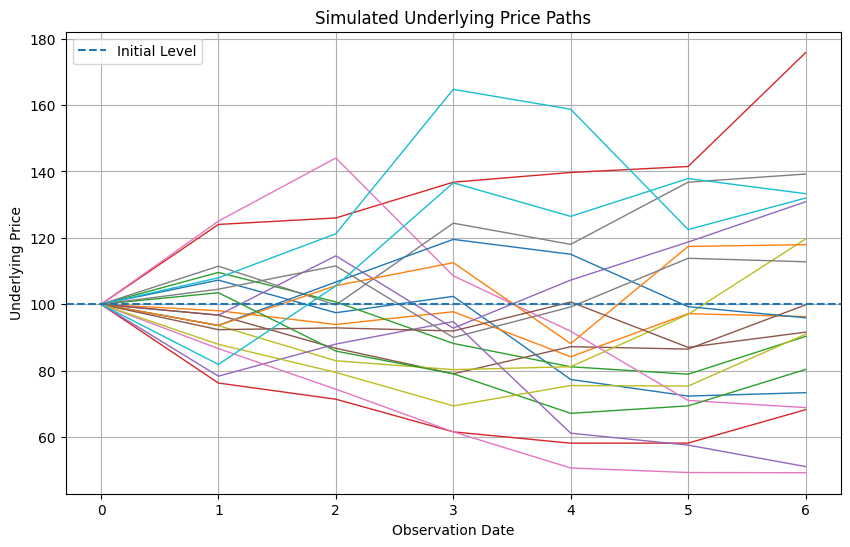

In [8]:
def plot_sample_paths(paths: np.ndarray, n_paths: int = 20) -> None:
    plt.figure(figsize=(10, 6))
    
    for i in range(min(n_paths, len(paths))):
        plt.plot(paths[i], linewidth=1)

    plt.axhline(INITIAL_PRICE, linestyle='--', label='Initial Level')
    plt.title("Simulated Underlying Price Paths")
    plt.xlabel("Observation Date")
    plt.ylabel("Underlying Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sample_paths(paths, n_paths=20)

In [9]:
final_prices = paths[:, -1]

summary_stats = pd.DataFrame({
    "Metric": ["Mean Final Price", "Median Final Price", "Min Final Price", "Max Final Price"],
    "Value": [
        final_prices.mean(),
        np.median(final_prices),
        final_prices.min(),
        final_prices.max()
    ]
})

print(summary_stats)

               Metric       Value
0    Mean Final Price  106.188921
1  Median Final Price  100.163855
2     Min Final Price   22.748459
3     Max Final Price  380.896121
